In [7]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')
import os
print("The files are in the current working directory:", os.getcwd())

The files are in the current working directory: /content


In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [9]:
!kaggle datasets list | head


ref                                                  title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                             Heart Disease                                   3491  2025-12-11 15:29:14.327000           2114        192  1.0              
ahmeduzaki/wind-and-solar-energy-production-dataset  Wind & Solar Energy Production Dataset        395372  2026-01-02 21:06:22.780000              0         33  1.0              
kundanbedmutha/exam-score-prediction-dataset         Exam Score Prediction Dataset                 325454  2025-11-28 07:29:01.047000           5863        243  1.0              
guriya79/heart-failure-prediction-dataset            Heart Failure Clinical Records Study            4067

In [10]:
!kaggle datasets download -d syedalinaqvi/augmented-skin-conditions-image-dataset


Dataset URL: https://www.kaggle.com/datasets/syedalinaqvi/augmented-skin-conditions-image-dataset
License(s): CC-BY-SA-4.0
 56% 152M/273M [00:00<00:00, 1.59GB/s]
100% 273M/273M [00:00<00:00, 970MB/s] 


In [11]:
!unzip augmented-skin-conditions-image-dataset.zip -d Skin_Conditions


Archive:  augmented-skin-conditions-image-dataset.zip
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_1.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_10.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_100.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_101.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_102.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_103.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_104.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_105.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_106.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_107.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_108.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_109.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_11.jpg  
  inflating: Skin_Conditions/Skin_Conditions/Acne/Acne_110.jpg  
  inflating: Skin_Conditions/Skin_Condit

In [12]:
import os
os.listdir("Skin_Conditions/Skin_Conditions")

['Milia', 'Acne', 'Rosacea', 'Carcinoma', 'Keratosis', 'Eczema']

In [13]:
dataset_dir = "Skin_Conditions/Skin_Conditions"

In [14]:
import os
print(os.listdir(dataset_dir))

['Milia', 'Acne', 'Rosacea', 'Carcinoma', 'Keratosis', 'Eczema']


In [15]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

In [16]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
SEED = 42
dataset_dir = "Skin_Conditions/Skin_Conditions"

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 2394 files belonging to 6 classes.
Using 1916 files for training.
Found 2394 files belonging to 6 classes.
Using 478 files for validation.
Classes: ['Acne', 'Carcinoma', 'Eczema', 'Keratosis', 'Milia', 'Rosacea']


In [18]:
NUM_CLASSES = len(class_names)
print(NUM_CLASSES)

6


In [19]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [20]:
labels = np.concatenate([y.numpy() for _, y in train_ds])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.9503968253968254), 1: np.float64(1.0137566137566139), 2: np.float64(1.020234291799787), 3: np.float64(0.9765545361875637), 4: np.float64(1.010548523206751), 5: np.float64(1.0334412081984898)}


In [21]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


In [22]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300, 300, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(300, 300, 3))
x = augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,579,701 (44.17 MB)

 Trainable params: 793,094 (3.03 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [24]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.2)
]

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 211ms/step - accuracy: 0.6202 - loss: 1.3453 - val_accuracy: 0.8138 - val_loss: 0.5198 - learning_rate: 0.0010
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - accuracy: 0.8019 - loss: 0.7413 - val_accuracy: 0.8703 - val_loss: 0.3593 - learning_rate: 0.0010
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.8293 - loss: 0.6156 - val_accuracy: 0.9059 - val_loss: 0.3404 - learning_rate: 0.0010
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.8641 - loss: 0.4641 - val_accuracy: 0.8996 - val_loss: 0.3070 - learning_rate: 0.0010
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.8559 - loss: 0.5001 - val_accuracy: 0.8870 - val_loss: 0.3769 - learning_rate: 0.0010
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.8714 - loss: 0.4712 - val_accuracy: 0.8745 - val_loss: 0.3857 - learning_rate: 0.0010
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.8

In [25]:
#2.5D

import tensorflow as tf

def generate_2_5d_channels(images):
    """
    images: Tensor of shape (B, H, W, 3), values in [0,255]
    returns: Tensor of shape (B, H, W, 6)
    """

    # Convert to grayscale
    gray = tf.image.rgb_to_grayscale(images)

    # Sobel gradients
    gx = tf.image.sobel_edges(gray)[..., 0]  # horizontal
    gy = tf.image.sobel_edges(gray)[..., 1]  # vertical

    # Simulated lighting directions
    left_light  = tf.nn.relu(-gx)
    right_light = tf.nn.relu(gx)
    top_light   = tf.nn.relu(-gy)

    # Normalize shading
    shading = tf.concat([left_light, right_light, top_light], axis=-1)
    shading = tf.math.l2_normalize(shading, axis=-1)

    # Stack RGB + shading
    enhanced = tf.concat([images, shading], axis=-1)

    return enhanced


In [26]:
def add_2_5d_to_batch(images, labels):
    images = tf.cast(images, tf.float32)
    enhanced = generate_2_5d_channels(images)
    return enhanced, labels

In [27]:
from tensorflow.keras import layers, models

model_2_5d = models.Sequential([
    layers.Input(shape=(300, 300, 6)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_2_5d.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2_5d.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 32)   │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,678 (502.65 KB)

 Trainable params: 128,678 (502.65 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (300, 300)  # Make sure this matches the image size used during training

# You can change 'r.jpg' to any image file you have in your Colab environment
img_path = "r.jpg"

# Load and preprocess the image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

print(f"Image '{img_path}' loaded and preprocessed. Shape: {img_array.shape}")

Image 'r.jpg' loaded and preprocessed. Shape: (1, 300, 300, 3)


In [29]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 50s 240ms/step - accuracy: 0.7861 - loss: 0.7449 - val_accuracy: 0.9079 - val_loss: 0.3236 - learning_rate: 1.0000e-05
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 25s 205ms/step - accuracy: 0.8146 - loss: 0.6120 - val_accuracy: 0.8954 - val_loss: 0.3560 - learning_rate: 1.0000e-05
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 25s 204ms/step - accuracy: 0.8347 - loss: 0.5485 - val_accuracy: 0.8891 - val_loss: 0.3587 - learning_rate: 1.0000e-05
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.8437 - loss: 0.4827 - val_accuracy: 0.8870 - val_loss: 0.3576 - learning_rate: 2.0000e-06
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 24s 204ms/step - accuracy: 0.8370 - loss: 0.4972 - val_accuracy: 0.8849 - val_loss: 0.3541 - learning_rate: 2.0000e-06


In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def test_custom_image(img_path, threshold=0.45):
    # Load image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    plt.imshow(img)
    plt.axis("off")

    # Preprocess
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Predict
    predictions = model.predict(img_array)[0]
    idx = np.argmax(predictions)
    confidence = predictions[idx]

    print("\nPredicted Condition:", class_names[idx])
    print(f"Confidence: {confidence * 100:.2f}%")

    if confidence < threshold:
        print("⚠️ Low confidence — model is uncertain")

    print("\nAll class probabilities:")
    for i, cls in enumerate(class_names):
        print(f"{cls}: {predictions[i] * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Predicted Condition: Acne
Confidence: 99.80%

All class probabilities:
Acne: 99.80%
Carcinoma: 0.00%
Eczema: 0.01%
Keratosis: 0.18%
Milia: 0.00%
Rosacea: 0.00%


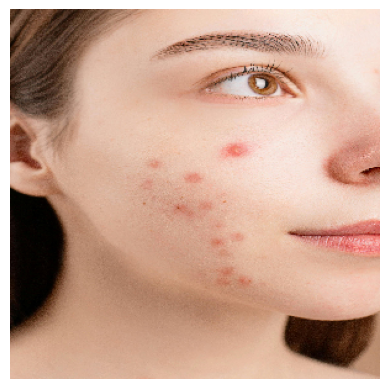

In [31]:
test_custom_image("4.jpg")


In [32]:
# Pick images directly from train_ds
for images, labels in train_ds.take(1):
    preds = model.predict(images)
    print("True:", labels.numpy()[:5])
    print("Pred:", np.argmax(preds, axis=1)[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
True: [1 0 1 3 1]
Pred: [1 0 1 3 1]


In [33]:
from collections import Counter

counter = Counter()
for _, labels in train_ds:
    counter.update(labels.numpy())

counter


Counter({np.int32(2): 313,
         np.int32(5): 309,
         np.int32(1): 315,
         np.int32(4): 316,
         np.int32(3): 327,
         np.int32(0): 336})

In [34]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

In [35]:
print(model)
print(val_ds)
print(class_names)


<Functional name=functional_1, built=True>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
['Acne', 'Carcinoma', 'Eczema', 'Keratosis', 'Milia', 'Rosacea']


In [36]:
class TemperatureScaling(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.temperature = tf.Variable(1.0, trainable=True)

    def call(self, logits):
        return logits / self.temperature


def fit_temperature(model, val_ds):
    logits_list = []
    labels_list = []

    for images, labels in val_ds:
        logits = model(images, training=False)
        logits_list.append(logits)
        labels_list.append(labels)

    logits = tf.concat(logits_list, axis=0)
    labels = tf.concat(labels_list, axis=0)

    temp_model = TemperatureScaling()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    for _ in range(300):
        with tf.GradientTape() as tape:
            scaled_logits = temp_model(logits)
            loss = tf.keras.losses.sparse_categorical_crossentropy(
                labels, tf.nn.softmax(scaled_logits)
            )
            loss = tf.reduce_mean(loss)

        grads = tape.gradient(loss, [temp_model.temperature])
        optimizer.apply_gradients(zip(grads, [temp_model.temperature]))

    print("✅ Optimal temperature:", temp_model.temperature.numpy())
    return temp_model


In [37]:
temp_model = fit_temperature(model, val_ds)

✅ Optimal temperature: 0.21422695


In [38]:
def calibrated_predict(model, temp_model, img_array):
    logits = model(img_array, training=False)
    scaled_logits = logits / temp_model.temperature
    probs = tf.nn.softmax(scaled_logits).numpy()[0]
    return probs

In [39]:
IMG_SIZE = (300, 300)  # MUST match training

img_path = "4.jpg"  # change if needed
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

print("img_array shape:", img_array.shape)

img_array shape: (1, 300, 300, 3)


In [40]:
preds = calibrated_predict(model, temp_model, img_array)

for cls, prob in zip(class_names, preds):
    print(f"{cls}: {prob:.3f}")

Acne: 0.955
Carcinoma: 0.009
Eczema: 0.009
Keratosis: 0.009
Milia: 0.009
Rosacea: 0.009


In [41]:
def top_k_predictions(probs, class_names, k=3):
    idxs = np.argsort(probs)[::-1][:k]
    return [(class_names[i], probs[i]) for i in idxs]

In [42]:
top_k = top_k_predictions(preds, class_names, k=3)

print("Top predictions:")
for cls, prob in top_k:
    print(f"{cls}: {prob:.2f}")

Top predictions:
Acne: 0.95
Keratosis: 0.01
Eczema: 0.01


In [43]:
def uncertainty_check(probs, threshold=0.6):
    if np.max(probs) < threshold:
        return "UNCERTAIN"
    return "CONFIDENT"

In [44]:
status = uncertainty_check(preds)

print("Confidence status:", status)

Confidence status: CONFIDENT


In [45]:
def safe_carcinoma_rule(top_k):
    for cls, prob in top_k:
        if cls == "Carcinoma" and prob < 0.8:
            return "SUSPICIOUS (needs dermatologist review)"
    return "SCREENING RESULT"

In [46]:
decision = safe_carcinoma_rule(top_k)
print("Final decision:", decision)

Final decision: SCREENING RESULT


In [47]:
def final_skin_analysis(preds, class_names):
    top_k = top_k_predictions(preds, class_names)
    status = uncertainty_check(preds)
    safety = safe_carcinoma_rule(top_k)

    return {
        "top_predictions": top_k,
        "confidence": status,
        "decision": safety
    }

In [48]:
result = final_skin_analysis(preds, class_names)

print(result)

{'top_predictions': [('Acne', np.float32(0.9546725)), ('Keratosis', np.float32(0.00912593)), ('Eczema', np.float32(0.009054005))], 'confidence': 'CONFIDENT', 'decision': 'SCREENING RESULT'}


In [49]:
import matplotlib.pyplot as plt

def plot_probs(probs, class_names):
    plt.barh(class_names, probs)
    plt.xlabel("Probability")
    plt.title("Model Confidence Distribution")
    plt.show()

In [50]:
import tensorflow as tf
import numpy as np
model.save("skin_model.h5")

In [51]:
import os
os.listdir()

['.config',
 'skin_model.h5',
 'kaggle.json',
 'Skin_Conditions',
 '3.png',
 'augmented-skin-conditions-image-dataset.zip',
 'r.jpg',
 '1.png',
 '4.jpg',
 '2.png',
 'sample_data']

In [52]:
print(model)

<Functional name=functional_1, built=True>


In [53]:
import pickle

with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

In [54]:
import os
os.listdir()

['.config',
 'skin_model.h5',
 'class_names.pkl',
 'kaggle.json',
 'Skin_Conditions',
 '3.png',
 'augmented-skin-conditions-image-dataset.zip',
 'r.jpg',
 '1.png',
 '4.jpg',
 '2.png',
 'sample_data']

In [55]:
import pickle

with open("temperature.pkl", "wb") as f:
    pickle.dump(float(temp_model.temperature.numpy()), f)

In [56]:
import os
os.listdir()

['.config',
 'skin_model.h5',
 'class_names.pkl',
 'kaggle.json',
 'Skin_Conditions',
 'temperature.pkl',
 '3.png',
 'augmented-skin-conditions-image-dataset.zip',
 'r.jpg',
 '1.png',
 '4.jpg',
 '2.png',
 'sample_data']

In [57]:
!zip -r skin_model.zip skin_model.h5


  adding: skin_model.h5 (deflated 9%)


In [58]:
import numpy as np
import tensorflow as tf

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

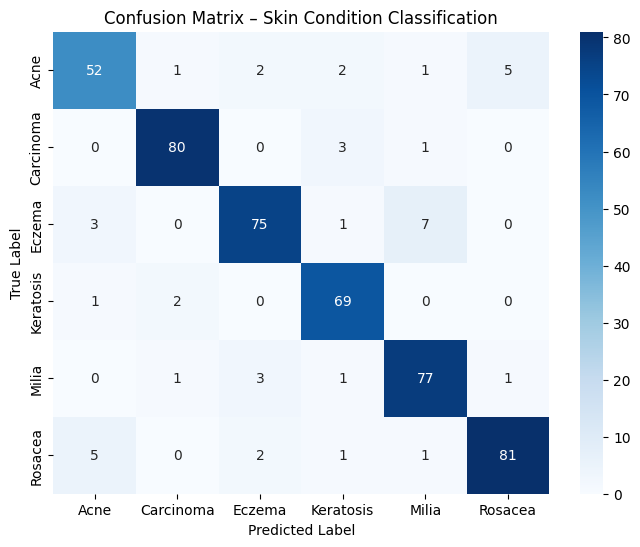

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Skin Condition Classification")
plt.show()

In [60]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        Acne       0.85      0.83      0.84        63
   Carcinoma       0.95      0.95      0.95        84
      Eczema       0.91      0.87      0.89        86
   Keratosis       0.90      0.96      0.93        72
       Milia       0.89      0.93      0.91        83
     Rosacea       0.93      0.90      0.92        90

    accuracy                           0.91       478
   macro avg       0.91      0.91      0.91       478
weighted avg       0.91      0.91      0.91       478

